<a href="https://colab.research.google.com/github/varshneypalak75-droid/Bootcamp_Notebook/blob/main/session5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df=pd.read_csv(url)


In [ ]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [ ]:
print(df.isna().sum())
print("duplicates:",df.duplicated().sum())

country            0
year               0
population         0
continent          0
life_expectancy    0
gdp_per_capita     0
dtype: int64
duplicates: 0


In [ ]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020

In [ ]:
life_exp_median= dirty_demo["life_expectancy"].median()
gdp_per_cap_median = dirty_demo["gdp_per_capita"].median()


dirty_demo["gdp_per_capita"] = dirty_demo["gdp_per_capita"].fillna(gdp_per_cap_median)

dirty_demo["life_expectancy"] = dirty_demo["life_expectancy"].fillna(life_exp_median)

In [ ]:
# pandas
# date range for the data
# number of countries/continents
min_year=df_clean['year'].min()
max_year=df_clean['year'].max()
print("Year Range:", min_year,"-",max_year)
print("number of countries:",df_clean['country'].nunique())
print("number of continents:",df_clean['continent'].nunique())
print("Average Life Expectancy:",df_clean['life_expectancy'].mean())
print("Min Life Expectancy:",df_clean['life_expectancy'].min())
print("Max Life Expectancy:",df_clean['life_expectancy'].max())


print(df_clean.describe())

Year Range: 1952 - 2007
number of countries: 142
number of continents: 5
Average Life Expectancy: 59.474439366197174
Min Life Expectancy: 23.599
Max Life Expectancy: 82.603
             year    population  life_expectancy  gdp_per_capita
count  1704.00000  1.704000e+03      1704.000000     1704.000000
mean   1979.50000  2.960121e+07        59.474439     7215.327081
std      17.26533  1.061579e+08        12.917107     9857.454543
min    1952.00000  6.001100e+04        23.599000      241.165876
25%    1965.75000  2.793664e+06        48.198000     1202.060309
50%    1979.50000  7.023596e+06        60.712500     3531.846988
75%    1993.25000  1.958522e+07        70.845500     9325.462346
max    2007.00000  1.318683e+09        82.603000   113523.132900


In [ ]:
# continents
print(df_clean['continent'].value_counts())
#latest data to be used

latest_year = df_clean["year"].max()
latest_df = df_clean[df_clean["year"] == latest_year].copy()

print("Latest year:", latest_year)
print(latest_df.head())
print(latest_df.shape)

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64
Latest year: 2007
        country  year  population continent  life_expectancy  gdp_per_capita
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338
23      Albania  2007   3600523.0    Europe           76.423     5937.029526
35      Algeria  2007  33333216.0    Africa           72.301     6223.367465
47       Angola  2007  12420476.0    Africa           42.731     4797.231267
59    Argentina  2007  40301927.0  Americas           75.320    12779.379640
(142, 6)


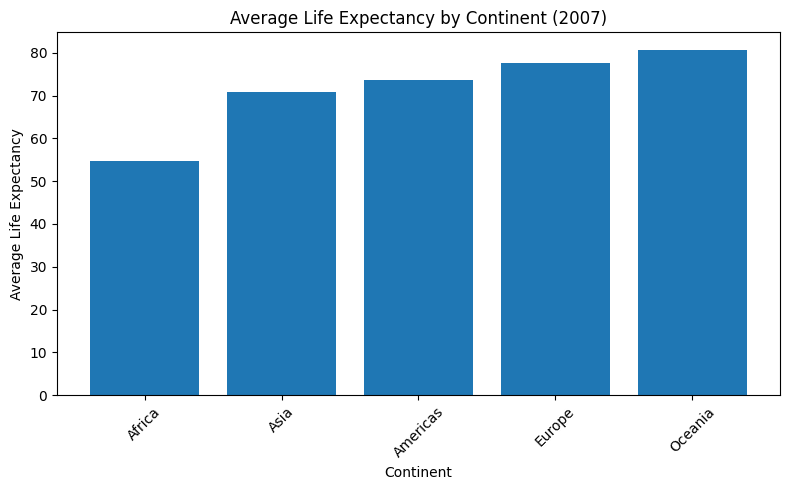

In [ ]:
#bar chart for avgerage life expectancy by continent

continent_life = latest_df.groupby("continent")["life_expectancy"].mean().sort_values()



plt.figure(figsize=(8,5))
plt.bar(continent_life.index, continent_life.values)
plt.title(f"Average Life Expectancy by Continent ({latest_year})")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")
plt.xticks(rotation=45)
plt.tight_layout()

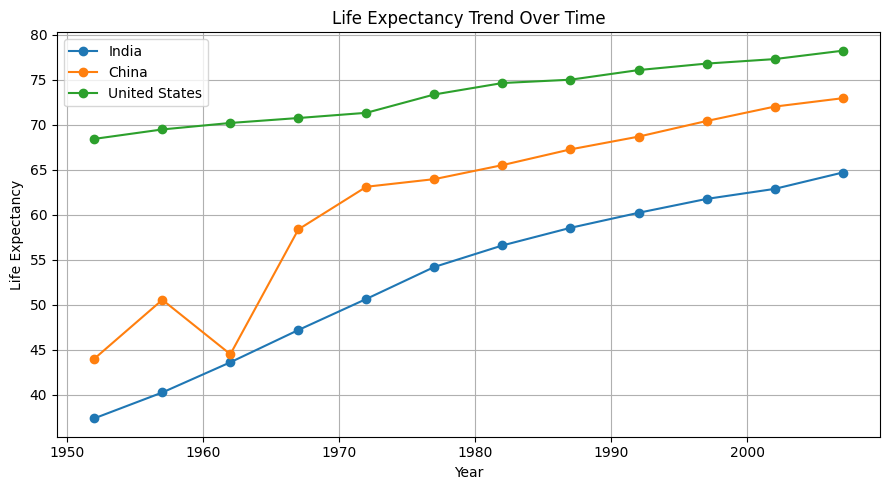

In [ ]:
#line chart for india, china and United states, life expectancy over time

selected_countries = ["India", "China", "United States"]
trend_df= df_clean[df_clean["country"].isin(selected_countries)]

plt.figure(figsize=(9,5))

for country in selected_countries:
    country_df= trend_df[trend_df["country"] == country]
    plt.plot(country_df["year"], country_df["life_expectancy"], marker="o", label=country)


plt.title("Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


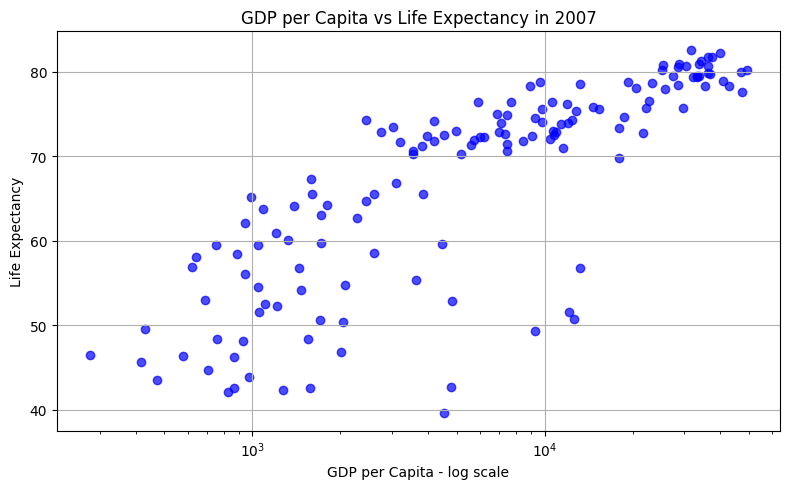

In [ ]:
#scatter plot for gdp per capita vs life expectancy

plt.figure(figsize=(8,5))
plt.scatter(
    latest_df["gdp_per_capita"],
    latest_df["life_expectancy"],
    alpha=0.7,
    color="blue"

)

plt.xscale("log")
plt.title(f"GDP per Capita vs Life Expectancy in {latest_year}")
plt.xlabel("GDP per Capita - log scale")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# regression demo model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

ml_df = df_clean.copy()
ml_df["log_gdp_per_capita"] = np.log(ml_df["gdp_per_capita"])
ml_df['log_population'] = np.log(ml_df["population"])

features_regression = ml_df[['year','log_gdp_per_capita','log_population']]

label_regression = ml_df['life_expectancy']


# splitting the data into 4 main parts: inputs for training and testing , targets for training and testing
X_train,X_test,Y_train,Y_test=train_test_split(
    features_regression,
    label_regression,
    test_size=0.2,
    random_state=42
)

print("training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

regression_model = LinearRegression()
regression_model.fit(X_train,Y_train)

y_pred = regression_model.predict(X_test)

# evaluation
mae = mean_absolute_error(Y_test,y_pred)
r2 = r2_score(Y_test,y_pred)

print("Mean Absolute Error:",mae)
print("R-Squared:",r2)

result_regression = pd.DataFrame({
    "actual_life_expectancy" : Y_test.values,
    "predicted_life_expectancy" : y_pred
})
print(result_regression.head(10))


training feature shape: (1363, 3)
Testing feature shape: (341, 3)
Mean Absolute Error: 4.806878361965181
R-Squared: 0.7548268469903197
   actual_life_expectancy  predicted_life_expectancy
0                  45.108                  40.108844
1                  68.900                  58.148565
2                  70.110                  62.892443
3                  54.655                  57.359970
4                  67.660                  62.573207
5                  50.254                  47.092771
6                  50.485                  48.878968
7                  75.250                  77.245661
8                  50.725                  50.785747
9                  70.670                  68.126280
